# Zernike Modes

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
from dataclasses import dataclass
from typing import List, Tuple

In [44]:
@dataclass
class ZernikeMode:
    n: int                  # radial order
    m: int                  # azimuthal
    weight: float           # coefficient/factor
    angular: str = "cos"    # "cos" or "sin"
    label: str = ""         # optional display label


In [177]:
def make_grid(size: int, grid_lim: float):
    # Square grid
    x = np.linspace(-grid_lim, grid_lim, size)
    y = np.linspace(-grid_lim, grid_lim, size)
    X, Y = np.meshgrid(x, y)

    # Circle mask
    rho = np.sqrt(X**2 + Y**2)
    theta = np.arctan2(Y, X)
    mask = rho <= 1.0

    return rho, theta, mask



# ZERNIKE POLYNOMIALS
def radial_polynomial(n: int, m: int, rho: np.ndarray):
    """
    Compute R_n^m(rho)
    """
    # Check assumptions
    if n < 0 or m < 0 or m > n or (n - m) % 2 != 0:
        return np.zeros_like(rho)

    R = np.zeros_like(rho, dtype=float)
    upper = (n - m) // 2

    for s in range(upper + 1):
        coeff = ((-1)**s * factorial(n - s)) / (
            factorial(s) *
            factorial((n + m)//2 - s) *
            factorial((n - m)//2 - s)
        )
        R += coeff * rho**(n - 2*s)

    return R


def zernike_mode(n: int, m: int, rho: np.ndarray, theta: np.ndarray,
                 mask: np.ndarray, angular: str = "cos"):
    """
    Calc Zernike mode as either
      Z_n^m = R_n^m(rho) * cos(m theta)   
      or
      Z_n^m = R_n^m(rho) * sin(m theta)
    """
    m_abs = abs(m)
    R = radial_polynomial(n, m_abs, rho)

    # if angular == "sin":
    #     Z = R * np.sin(m_abs * theta)
    # else:
    #     Z = R * np.cos(m_abs * theta)
    if m == 0:
        Z = np.sqrt(n + 1) * R
    else:
        Z = np.sqrt(2 * (n + 1)) * R * (np.cos(m_abs * theta) + np.sin(m_abs * theta))
    return Z



# PHASE SCREEN
def build_phase_screen(modes: List[ZernikeMode], grid_lim: float, size: int):
    """
    Generate all weighted modes and their sum
    """
    rho, theta, mask = make_grid(size, grid_lim)

    mode_images = []
    weighted_images = []
    phase_sum = np.zeros((size, size), dtype=float)

    for mode in modes:
        # Calculate Zernike Polinomial, multiply by weight and sum
        Z = zernike_mode(mode.n, mode.m, rho, theta, mask, angular=mode.angular)
        WZ = mode.weight * Z
        mode_images.append(Z)
        weighted_images.append(WZ)
        phase_sum += WZ

    return rho, theta, mask, mode_images, weighted_images, phase_sum


# MAP PHASE TO 8-BIT SLM IMAGE
def phase_to_slm_gray(phase: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """
    Crop img
    Wrap phase into [0, 2pi) and map to 8-bit grayscale [0, 255]
    """
    rows, cols = np.where(mask)

    if len(rows) == 0 or len(cols) == 0:
        raise ValueError("Mask contains no True values.")

    rmin, rmax = rows.min(), rows.max()
    cmin, cmax = cols.min(), cols.max()

    phase_crop = phase[rmin:rmax+1, cmin:cmax+1]
    mask_crop = mask[rmin:rmax+1, cmin:cmax+1]

    wrapped = np.mod(phase_crop, 2 * np.pi)
    gray = np.uint8(np.round((wrapped / (2 * np.pi)) * 255))
    gray[~mask_crop] = 0

    return gray


# PLOTTING
def plot_modes_and_sum(modes: List[ZernikeMode],
                       mode_images: List[np.ndarray],
                       weighted_images: List[np.ndarray],
                       phase_sum: np.ndarray,
                       grid_lim: float,
                       cmap: str = "gray"):
    """
    Plot each weighted mode with its factor and the final summed phase screen.
    """
    n_modes = len(modes)
    n_total = n_modes + 1  # modes + summed phase
    n_cols = int(np.ceil(n_total / 2))

    fig, axes = plt.subplots(2, n_cols, figsize=(3.2 * n_cols, 7.2))
    axes = np.array(axes).reshape(-1)
    extent = [-grid_lim, grid_lim, -grid_lim, grid_lim]

    # Individual Modes Graphs
    for i, (mode, img) in enumerate(zip(modes, weighted_images)):
        ax = axes[i]
        im = ax.imshow(
            img,
            # np.mod(img, 2 * np.pi),
            cmap=cmap,
            origin="lower",
            extent=extent
        )

        ax.set_title(
            f"{mode.label or f'Z({mode.n},{mode.m})'}\n"
            f"factor = {mode.weight:+.3f}",
            fontsize=10
        )
        ax.set_xticks([])
        ax.set_yticks([])

        # Gen unit circle in the middle
        circle = plt.Circle(
            (0, 0),
            1,
            fill=False,
            color="lightblue",
            linewidth=1.0
        )
        ax.add_patch(circle)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Summed Phase Graph
    ax = axes[n_modes]
    im = ax.imshow(
        np.mod(phase_sum, 2 * np.pi),
        cmap=cmap,
        origin="lower",
        extent=extent
    )
    ax.set_title("Summed phase screen", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

    # Gen unit circle in the middle
    circle = plt.Circle(
        (0, 0),
        1,
        fill=False,
        color="lightblue",
        linewidth=1.0
    )
    ax.add_patch(circle)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Hide any unused subplots
    for j in range(n_total, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


def plot_slm_image(slm_gray: np.ndarray):
    """
    Plot the 8-bit grayscale image
    """
    plt.figure(figsize=(5, 5))
    plt.imshow(slm_gray, cmap="gray", origin="lower", vmin=0, vmax=255)
    plt.title("8-bit grayscale SLM image")
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show()


# SAVE IMAGE
def save_slm_image(filename: str, slm_gray: np.ndarray):
    """
    Save the SLM image as PNG.
    """
    plt.imsave(filename, slm_gray, cmap="gray", vmin=0, vmax=255)

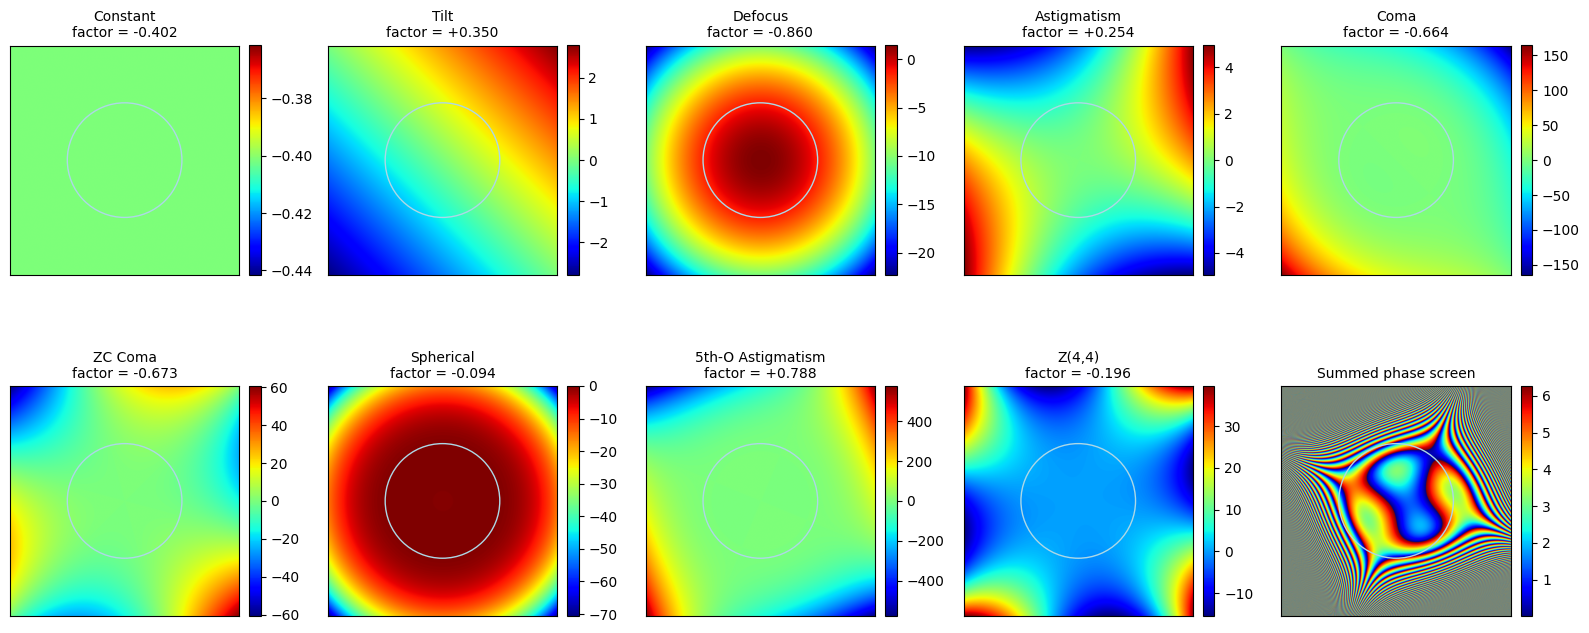

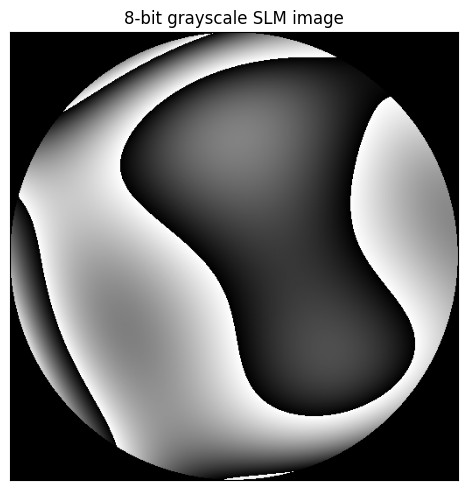

In [186]:
# Example mode set similar to the Burger Fig. 2 idea:
# tilt, defocus, coma, astigmatism, spherical

np.random.seed(69)
grid_lim=2
size=1024

modes = [
    ZernikeMode(n=1, m=1, weight=-0.8713, angular="cos", label="Tilt"),
    ZernikeMode(n=2, m=0, weight=-0.07224, angular="cos", label="Defocus"),
    ZernikeMode(n=2, m=2, weight= 0.0151, angular="cos", label="Astigmatism"),
    ZernikeMode(n=3, m=1, weight= 0.09276, angular="cos", label="Coma"),
    ZernikeMode(n=3, m=3, weight= 0.09276, angular="cos", label="ZC Coma"),
    ZernikeMode(n=4, m=0, weight=-0.0587, angular="cos", label="Spherical"),
]
modes = [
    ZernikeMode(n=0, m=0, weight=np.random.choice((-1,1)) * np.random.random(), angular="cos", label="Constant"),
    ZernikeMode(n=1, m=1, weight=np.random.choice((-1,1)) * np.random.random(), angular="cos", label="Tilt"),
    ZernikeMode(n=2, m=0, weight=np.random.choice((-1,1)) * np.random.random(), angular="cos", label="Defocus"),
    ZernikeMode(n=2, m=2, weight=np.random.choice((-1,1)) * np.random.random(), angular="cos", label="Astigmatism"),
    ZernikeMode(n=3, m=1, weight=np.random.choice((-1,1)) * np.random.random(), angular="cos", label="Coma"),
    ZernikeMode(n=3, m=3, weight=np.random.choice((-1,1)) * np.random.random(), angular="cos", label="ZC Coma"),
    ZernikeMode(n=4, m=0, weight=np.random.choice((-1,1)) * np.random.random(), angular="cos", label="Spherical"),
    ZernikeMode(n=4, m=2, weight=np.random.choice((-1,1)) * np.random.random(), angular="cos", label="5th-O Astigmatism"),
    ZernikeMode(n=4, m=4, weight=np.random.choice((-1,1)) * np.random.random(), angular="cos", label=""),
]

# Generate modes and summed phase screen
rho, theta, mask, mode_images, weighted_images, phase_sum = build_phase_screen(
    modes=modes,
    grid_lim=grid_lim,
    size=size
)

# Show weighted modes and final summed phase screen
plot_modes_and_sum(modes, mode_images, weighted_images, phase_sum, grid_lim, cmap='jet')

# Convert summed phase to 8-bit grayscale for SLM
slm_gray = phase_to_slm_gray(phase_sum, mask)

# Show and save SLM image
plot_slm_image(slm_gray)
# save_slm_image("slm_phase_screen.png", slm_gray)